In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torchdiffeq

In [3]:
import os
import gc
import ast
import ast
import pywt
import copy
import torch
import joblib
import tempfile
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import torch.nn as nn
import tensorflow as tf
from tqdm.auto import tqdm
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


path='/content/drive/Shareddrives/XAI Project Shared Drive'
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [4]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dict):
    tmp = []
    for key in y_dict.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df_ptbxl[sc] = df_ptbxl['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

print("\nSample of Superclass Targets:")
display(df_ptbxl[['diagnostic_superclass'] + superclasses].head())


Sample of Superclass Targets:


,diagnostic_superclass,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0


In [5]:
class PTBXLDataset(Dataset):
    """PyTorch Dataset for PTB-XL ECG signals and multi-label targets."""
    def __init__(self, X, y):
        # Convert to float32 for PyTorch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class DataPipeline:
    """Handles splitting and DataLoader creation."""
    def __init__(self, X, df, target_cols, batch_size=256):
        self.X = X
        self.y = df[target_cols].values
        self.batch_size = batch_size

    def create_splits(self):
        # Standard split: 70% Train, 15% Val, 15% Test [cite: 95]
        X_temp, X_test, y_temp, y_test = train_test_split(
            self.X, self.y, test_size=0.15, random_state=42
        )
        # 15 / 0.85 approx 0.176
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=0.1764, random_state=42
        )

        datasets = {
            'train': PTBXLDataset(X_train, y_train),
            'val': PTBXLDataset(X_val, y_val),
            'test': PTBXLDataset(X_test, y_test)
        }

        loaders = {
            split: DataLoader(ds, batch_size=self.batch_size, shuffle=(split == 'train'))
            for split, ds in datasets.items()
        }
        return loaders, datasets

In [6]:
class ECGPreprocessor:
    """Handles normalization and denoising with persistence."""
    def __init__(self, save_path='preprocessor.joblib'):
        self.scaler = StandardScaler()
        self.save_path = save_path

    def fit_transform(self, X_train):
        samples, time_steps, leads = X_train.shape
        X_train_reshaped = X_train.reshape(-1, leads)
        X_train_scaled = self.scaler.fit_transform(X_train_reshaped)
        self.save()
        return X_train_scaled.reshape(samples, time_steps, leads)

    def transform(self, X):
        samples, time_steps, leads = X.shape
        X_reshaped = X.reshape(-1, leads)
        X_scaled = self.scaler.transform(X_reshaped)
        return X_scaled.reshape(samples, time_steps, leads)

    def save(self):
        joblib.dump(self.scaler, self.save_path)
        print(f"Preprocessor saved to {self.save_path}")

    def load(self):
        if os.path.exists(self.save_path):
            self.scaler = joblib.load(self.save_path)
            print(f"Preprocessor loaded from {self.save_path}")
            return True
        return False

In [7]:
class ODEFunc(nn.Module):
    """The neural network parameterizing the derivative of the hidden state."""
    def __init__(self, latent_dim=45):
        super(ODEFunc, self).__init__()
        # 2 layers, width 50, Tanh activations
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, latent_dim)
        )

    def forward(self, t, y):
        return self.net(y)

class LatentODEEncoder(nn.Module):
    """Encodes the ECG time-series into a single latent vector z0."""
    def __init__(self, input_dim=12, hidden_dim=45, latent_dim=45):
        super(LatentODEEncoder, self).__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.hidden_to_latent = nn.Linear(hidden_dim, latent_dim)
        self.ode_func = ODEFunc(latent_dim)

    def forward(self, x, time_steps):
        # x shape: (batch, time, leads)
        # 1. Encode via RNN backwards through time (standard for Latent ODEs)
        x_reversed = torch.flip(x, dims=[1])
        _, hidden = self.rnn(x_reversed)

        # 2. Map to latent space [cite: 60]
        z0 = self.hidden_to_latent(hidden[-1])

        # Note: In a full generative training loop, you would use odeint here
        # to reconstruct the sequence. For feature extraction, z0 is our target.
        return z0

class FeatureExtractorPipeline:
    """Wraps the trained ODE model to extract features for the GBDT."""
    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device

    def extract(self, dataloader):
        self.model.eval()
        latent_vectors = []
        labels = []

        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(self.device)
                time_steps = torch.linspace(0., 1., x.shape[1]).to(self.device)
                z0 = self.model(x, time_steps)

                latent_vectors.append(z0.cpu().numpy())
                labels.append(y.numpy())

        return np.vstack(latent_vectors), np.vstack(labels)

In [8]:
class GenerativeLatentODE(nn.Module):
    """Full Generative Latent ODE architecture."""
    def __init__(self, encoder, ode_func, latent_dim=45, output_dim=12):
        super(GenerativeLatentODE, self).__init__()
        self.encoder = encoder
        self.ode_func = ode_func
        # Decoder maps the latent state z_t back to the 12-lead ECG signal
        self.decoder = nn.Linear(latent_dim, output_dim)

    def forward(self, x, time_steps):
        # 1. Encode the entire sequence into a single starting latent vector z0
        z0 = self.encoder(x, time_steps)

        # 2. Solve the ODE forward in time to get the latent trajectory z_t
        # odeint expects time_steps to be 1D. It returns shape: (time, batch, latent_dim)
        z_t = odeint(self.ode_func, z0, time_steps, method='rk4')

        # Reshape to (batch, time, latent_dim) for easier handling
        z_t = z_t.permute(1, 0, 2)

        # 3. Decode the latent trajectory back into the ECG signal space
        x_pred = self.decoder(z_t)

        return x_pred, z_t

In [9]:
def path_minimized_loss(x_true, x_pred, z_t, lambda_reg=1e-3):
    """
    Calculates reconstruction loss + L2 path regularization.
    """
    # 1. Reconstruction Loss (Mean Squared Error)
    recon_loss = nn.MSELoss()(x_pred, x_true)

    # 2. L2 Path Regularization
    # Calculate the point-to-point distance in the latent trajectory: ||z_i - z_{i-1}||_2^2
    # z_t shape is (batch, time, latent_dim)
    diffs = z_t[:, 1:, :] - z_t[:, :-1, :]

    # Calculate the L2 norm along the latent dimension, then take the mean
    path_loss = torch.mean(torch.norm(diffs, p=2, dim=2))

    # Total loss
    total_loss = recon_loss + (lambda_reg * path_loss)

    return total_loss, recon_loss, path_loss

In [10]:
class LatentODETrainer:
    def __init__(self, model, dataloaders, device, lr=1e-3, epochs=20, patience=5, save_path='best_latent_ode.pth'):
        self.model = model.to(device)
        self.dataloaders = dataloaders
        self.device = device
        self.epochs = epochs
        self.patience = patience
        self.save_path = save_path
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Tracking metrics for plotting
        self.history = {'train_loss': [], 'val_loss': []}

    def train(self):
        print("Starting Latent ODE Training...")
        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())

        epoch_pbar = tqdm(range(self.epochs), desc="Epochs")
        for epoch in epoch_pbar:
            self.model.train()
            train_loss = 0.0

            # TQDM for training batches
            train_loader = tqdm(self.dataloaders['train'], leave=False, desc=f"Train Epoch {epoch+1}")
            for x_batch, _ in train_loader:
                x_batch = x_batch.to(self.device)
                time_steps = torch.linspace(0., 1., x_batch.shape[1]).to(self.device)

                self.optimizer.zero_grad()
                x_pred, z_t = self.model(x_batch, time_steps)
                loss, recon, path = path_minimized_loss(x_batch, x_pred, z_t)

                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()
                train_loader.set_postfix({'loss': f"{loss.item():.4f}"})

            avg_train_loss = train_loss / len(self.dataloaders['train'])
            avg_val_loss = self._validate()

            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)

            epoch_pbar.set_postfix({'Train': f"{avg_train_loss:.4f}", 'Val': f"{avg_val_loss:.4f}"})

            # Early Stopping Logic
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(best_model_wts, self.save_path)
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.patience:
                    print(f"\nEarly stopping triggered after {epoch + 1} epochs!")
                    break

        print(f"Training Complete. Best Val Loss: {best_val_loss:.4f}")
        self.model.load_state_dict(best_model_wts) # Load best weights
        self.plot_losses()
        return self.model

    def _validate(self):
        self.model.eval()
        val_loss = 0.0
        val_loader = tqdm(self.dataloaders['val'], leave=False, desc="Validating")
        with torch.no_grad():
            for x_batch, _ in val_loader:
                x_batch = x_batch.to(self.device)
                time_steps = torch.linspace(0., 1., x_batch.shape[1]).to(self.device)

                x_pred, z_t = self.model(x_batch, time_steps)
                loss, _, _ = path_minimized_loss(x_batch, x_pred, z_t)
                val_loss += loss.item()

        return val_loss / len(self.dataloaders['val'])

    def plot_losses(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.title('Latent ODE Training curve')
        plt.xlabel('Epochs')
        plt.ylabel('Loss (Recon + L2 Path)')
        plt.legend()
        plt.grid(True)
        plt.savefig('latent_ode_loss.png')
        plt.show()

In [11]:
def focal_loss_objective(preds, dtrain):
    """
    Custom Focal Loss gradient and hessian for XGBoost.
    Designed for binary classification (used within MultiOutputClassifier).
    """
    labels = dtrain
    # Convert predictions to probabilities using sigmoid
    probs = 1.0 / (1.0 + np.exp(-preds))

    alpha = 0.25
    gamma = 2.0

    # Gradient calculation
    grad = (probs - labels) * (
        alpha * labels * np.power(1 - probs, gamma) +
        (1 - alpha) * (1 - labels) * np.power(probs, gamma)
    )

    # Hessian calculation (simplified approximation for numerical stability)
    hess = np.maximum(probs * (1 - probs), 1e-4) * (
        alpha * labels * np.power(1 - probs, gamma) +
        (1 - alpha) * (1 - labels) * np.power(probs, gamma)
    )

    return grad, hess


In [12]:
import xgboost as xgb
import numpy as np

class GBDTMultiLabelClassifier:
    """Multi-Label GBDT wrapper using native log-loss and scale_pos_weight."""
    def __init__(self, target_names):
        self.target_names = target_names
        self.models = {}
        self.history = {}

    def fit(self, Z_train, y_train, Z_val, y_val):
        for i, target in enumerate(self.target_names):
            print(f"\n--- Training GBDT for target: {target} ---")

            # Calculate scale_pos_weight to handle class imbalance natively
            # spw = sum(negative instances) / sum(positive instances)
            pos_count = np.sum(y_train[:, i] == 1)
            neg_count = len(y_train[:, i]) - pos_count
            spw = neg_count / max(pos_count, 1) # Prevent division by zero

            print(f"[{target}] Imbalance Ratio (Neg/Pos): {spw:.2f}")

            model = xgb.XGBClassifier(
                n_estimators=1000,
                max_depth=6,             # Slightly reduced from 8 to prevent early overfitting
                learning_rate=0.05,
                objective='binary:logistic', # Native, perfectly stable log-loss
                scale_pos_weight=spw,        # Punishes the model heavily for missing the minority class
                tree_method='hist',
                random_state=42,
                early_stopping_rounds=50,
                eval_metric='aucpr'
            )

            model.fit(
                Z_train, y_train[:, i],
                eval_set=[(Z_train, y_train[:, i]), (Z_val, y_val[:, i])],
                verbose=50 # Print progress every 50 trees
            )

            self.models[target] = model
            self.history[target] = model.evals_result()

    def predict_proba(self, Z):
        """Standard predict_proba handling."""
        preds = []
        for target in self.target_names:
            # Native objective allows us to use standard predict_proba safely
            probs = self.models[target].predict_proba(Z)[:, 1]
            preds.append(probs)
        return np.column_stack(preds)

    def predict(self, Z, threshold=0.5):
        probs = self.predict_proba(Z)
        return (probs >= threshold).astype(int)

def plot_gbdt_learning_curves(classifier, save_path):
    """Plots the training vs validation AUCPR for each superclass."""
    fig, axes = plt.subplots(1, len(classifier.target_names), figsize=(20, 4))

    for i, target in enumerate(classifier.target_names):
        results = classifier.history[target]
        epochs = len(results['validation_0']['aucpr'])
        x_axis = range(0, epochs)

        axes[i].plot(x_axis, results['validation_0']['aucpr'], label='Train')
        axes[i].plot(x_axis, results['validation_1']['aucpr'], label='Val')
        axes[i].legend()
        axes[i].set_title(f'{target} - AUCPR')
        axes[i].set_xlabel('Number of Trees')
        axes[i].set_ylabel('AUCPR Score')

    plt.tight_layout()
    plt.savefig(os.path.join(save_path, 'gbdt_learning_curves.png'))
    plt.show()

In [13]:

class GBDTClassifier:
    """Multi-label GBDT using the paper's hyperparameters."""
    def __init__(self):
        # 1000 trees, max depth of 8
        base_estimator = xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=8,
            learning_rate=0.05,
            objective=focal_loss_objective,
            tree_method='hist', # Faster for larger datasets
            random_state=42,
            verbose=0
        )
        # Wrap for multi-label classification
        self.model = MultiOutputClassifier(base_estimator)

    def fit(self, Z_train, y_train):
        self.model.fit(Z_train, y_train)

    def predict_proba(self, Z):
        # MultiOutputClassifier returns a list of arrays; we stack them into (samples, classes)
        preds = self.model.predict_proba(Z)
        return np.column_stack([p[:, 1] for p in preds])

In [14]:
class FeatureExtractorPipeline:
    def __init__(self, model, device='cpu', save_dir='features'):
        self.model = model.to(device)
        self.device = device
        self.save_dir = save_dir
        os.makedirs(self.save_dir, exist_ok=True)

    def extract(self, dataloader, split_name):
        feature_path = f"{self.save_dir}/Z_{split_name}.npy"
        label_path = f"{self.save_dir}/y_{split_name}.npy"

        # Load if already computed
        if os.path.exists(feature_path) and os.path.exists(label_path):
            print(f"Loading cached features for {split_name}...")
            return np.load(feature_path), np.load(label_path)

        print(f"Extracting features for {split_name}...")
        self.model.eval()
        latent_vectors, labels = [], []

        loader_pbar = tqdm(dataloader, desc=f"Extracting {split_name}")
        with torch.no_grad():
            for x, y in loader_pbar:
                x = x.to(self.device)
                time_steps = torch.linspace(0., 1., x.shape[1]).to(self.device)
                z0 = self.model(x, time_steps)

                latent_vectors.append(z0.cpu().numpy())
                labels.append(y.numpy())

        Z = np.vstack(latent_vectors)
        Y = np.vstack(labels)

        # Save for future runs
        np.save(feature_path, Z)
        np.save(label_path, Y)
        return Z, Y

In [15]:
BASE_PATH = '/content/drive/Shareddrives/XAI Project Shared Drive/GBDT_ODE'
os.makedirs(BASE_PATH, exist_ok=True)

# Define specific file paths within your Shared Drive
PREPROCESSOR_PATH = os.path.join(BASE_PATH, 'ecg_preprocessor.joblib')
ODE_MODEL_PATH = os.path.join(BASE_PATH, 'best_latent_ode.pth')
FEATURES_DIR = os.path.join(BASE_PATH, 'features')
CLASSIFIER_PATH = os.path.join(BASE_PATH, 'gbdt_classifier.joblib')

In [16]:
target_cols = superclasses
data_pipeline = DataPipeline(X, df_ptbxl, target_cols)
loaders, datasets = data_pipeline.create_splits()

X_train_raw = datasets['train'].X.numpy()
X_val_raw = datasets['val'].X.numpy()
X_test_raw = datasets['test'].X.numpy()

In [17]:
preprocessor = ECGPreprocessor(save_path=PREPROCESSOR_PATH)
if preprocessor.load():
    X_train_proc = preprocessor.transform(X_train_raw)
else:
    X_train_proc = preprocessor.fit_transform(X_train_raw)
X_val_proc = preprocessor.transform(X_val_raw)
X_test_proc = preprocessor.transform(X_test_raw)

# Update datasets in-place
datasets['train'].X = torch.tensor(X_train_proc, dtype=torch.float32)
datasets['val'].X = torch.tensor(X_val_proc, dtype=torch.float32)
datasets['test'].X = torch.tensor(X_test_proc, dtype=torch.float32)

Preprocessor loaded from /content/drive/Shareddrives/XAI Project Shared Drive/GBDT_ODE/ecg_preprocessor.joblib


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ode_func = ODEFunc(latent_dim=45)
encoder = LatentODEEncoder(input_dim=12, hidden_dim=45, latent_dim=45)
generative_ode = GenerativeLatentODE(encoder=encoder, ode_func=ode_func, latent_dim=45, output_dim=12)

# 3. Train or Load Latent ODE
print("\n--- Step 3: Latent ODE Training/Loading ---")
if os.path.exists(ODE_MODEL_PATH):
    print(f"Loading pre-trained Latent ODE weights from {ODE_MODEL_PATH}...")
    generative_ode.load_state_dict(torch.load(ODE_MODEL_PATH, map_location=device))
else:
    trainer = LatentODETrainer(
        model=generative_ode,
        dataloaders=loaders,
        device=device,
        epochs=20,
        patience=5,
        save_path=ODE_MODEL_PATH
    )
    generative_ode = trainer.train()

    # Save the training plot to the drive as well
    import matplotlib.pyplot as plt
    plt.savefig(os.path.join(BASE_PATH, 'latent_ode_loss.png'))
    plt.close()


--- Step 3: Latent ODE Training/Loading ---
Loading pre-trained Latent ODE weights from /content/drive/Shareddrives/XAI Project Shared Drive/GBDT_ODE/best_latent_ode.pth...


In [19]:
extractor = FeatureExtractorPipeline(generative_ode.encoder, device=device, save_dir=FEATURES_DIR)
Z_train, y_train = extractor.extract(loaders['train'], 'train')
Z_val, y_val = extractor.extract(loaders['val'], 'val')
Z_test, y_test = extractor.extract(loaders['test'], 'test')

Loading cached features for train...
Loading cached features for val...
Loading cached features for test...


In [20]:
classifier = GBDTMultiLabelClassifier(target_names=superclasses)

if os.path.exists(CLASSIFIER_PATH):
    print(f"Loading trained GBDT classifier from {CLASSIFIER_PATH}...")
    classifier = joblib.load(CLASSIFIER_PATH)
else:
    print("Training Multi-Label GBDT with Focal Loss...")
    # Now we pass both Train AND Val sets to fit()
    classifier.fit(Z_train, y_train, Z_val, y_val)

    joblib.dump(classifier, CLASSIFIER_PATH)
    print(f"GBDT Classifier saved to {CLASSIFIER_PATH}.")

    # Plot and save the learning curves immediately after training
    print("Generating learning curves...")
    plot_gbdt_learning_curves(classifier, save_path=BASE_PATH)

Loading trained GBDT classifier from /content/drive/Shareddrives/XAI Project Shared Drive/GBDT_ODE/gbdt_classifier.joblib...


In [21]:
# import accuracy_score and roc_auc_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

In [22]:
y_pred_probs = classifier.predict_proba(Z_test)
y_pred = classifier.predict(Z_test, threshold=0.5)

print("\n[TEST SET METRICS]")
# Exact match means the model got ALL labels perfectly correct for a patient
print(f"Exact Match Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro ROC-AUC: {roc_auc_score(y_test, y_pred_probs, average='macro'):.4f}")

print("\nClassification Report (Per Superclass):")
# Scikit-learn's classification report handles multi-label elegantly
print(classification_report(
    y_test,
    y_pred,
    target_names=superclasses,
    zero_division=0
))


[TEST SET METRICS]
Exact Match Accuracy: 0.2364
Macro ROC-AUC: 0.6271

Classification Report (Per Superclass):
              precision    recall  f1-score   support

        NORM       0.53      0.61      0.57      1442
          MI       0.35      0.43      0.39       776
        STTC       0.31      0.35      0.33       792
          CD       0.42      0.36      0.39       778
         HYP       0.27      0.33      0.30       380

   micro avg       0.41      0.45      0.43      4168
   macro avg       0.38      0.42      0.39      4168
weighted avg       0.41      0.45      0.43      4168
 samples avg       0.39      0.47      0.41      4168



In [23]:
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import xgboost as xgb

class XAIPipeline:
    """A suite of 4 xAI techniques tailored for the custom Multi-Label GBDT."""
    def __init__(self, classifier, target_name, Z_train, Z_test, y_test, feature_names=None):
        self.classifier = classifier
        self.target = target_name
        self.model = classifier.models[target_name] # Extract the specific XGBoost model
        self.Z_train = Z_train
        self.Z_test = Z_test

        # Get the specific binary targets for this class
        target_idx = classifier.target_names.index(target_name)
        self.y_test = y_test[:, target_idx]

        # If no names provided, name them 'Latent_0', 'Latent_1', etc.
        if feature_names is None:
            self.feature_names = [f"Latent_{i}" for i in range(Z_train.shape[1])]
        else:
            self.feature_names = feature_names

    def run_technique_1_native_importance(self):
        """
        1. Built-in XGBoost Feature Importance (Global)
        Measures 'Gain': the relative contribution of the corresponding feature
        to the model calculated by taking each feature's contribution for each tree.
        """
        print(f"\n--- 1. Native XGBoost Importance (Gain) for {self.target} ---")
        plt.figure(figsize=(10, 6))
        # xgb.plot_importance plots directly to the current matplotlib axis
        xgb.plot_importance(
            self.model,
            importance_type='gain',
            max_num_features=10,
            title=f'Top 10 Latent Features by Gain ({self.target})'
        )
        plt.show()

    def run_technique_2_shap_explanations(self):
        """
        2. SHAP (SHapley Additive exPlanations) (Global & Local)
        The gold standard for tree models. Shows how much each feature pushes the
        model output from the base value to the final prediction.
        """
        print(f"\n--- 2. SHAP Analysis for {self.target} ---")


        explainer = shap.TreeExplainer(self.model)

        Z_sample = self.Z_test[:1000] if len(self.Z_test) > 1000 else self.Z_test
        shap_values = explainer(Z_sample)

        # A. Global Interpretability: Summary Plot
        print("Generating Global SHAP Summary Plot...")
        shap.summary_plot(shap_values, Z_sample, feature_names=self.feature_names)

        # B. Local Interpretability: Waterfall Plot for a single patient (Patient 0)
        print("Generating Local SHAP Waterfall Plot for Patient 0...")
        shap.plots.waterfall(shap_values[0])

    def run_technique_3_permutation_importance(self):
        """
        3. Permutation Feature Importance (Global)
        Measures the decrease in a model score when a single feature value is randomly shuffled.
        Breaks the relationship between the feature and the target.
        """
        print(f"\n--- 3. Permutation Importance for {self.target} ---")

        result = permutation_importance(
            self.model, self.Z_test, self.y_test,
            n_repeats=5, random_state=42, n_jobs=-1, scoring='average_precision'
        )

        # Sort features by importance
        sorted_idx = result.importances_mean.argsort()[-10:] # Top 10

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.boxplot(result.importances[sorted_idx].T, vert=False,
                   labels=np.array(self.feature_names)[sorted_idx])
        ax.set_title(f"Permutation Importances (Test Set AUCPR Drop) - {self.target}")
        ax.set_xlabel("Decrease in AUCPR score")
        fig.tight_layout()
        plt.show()

    def run_technique_4_partial_dependence(self):
        """
        4. Partial Dependence Plots (PDP) (Global)
        Shows the marginal effect one or two features have on the predicted outcome.
        Helps identify if the relationship is linear, monotonic, or more complex.
        """
        print(f"\n--- 4. Partial Dependence Plots for {self.target} ---")

        # First, find the top 3 most important features using native importance
        importance = self.model.feature_importances_
        top_3_idx = importance.argsort()[-3:][::-1]

        print(f"Plotting PDP for top 3 features: {[self.feature_names[i] for i in top_3_idx]}")

        fig, ax = plt.subplots(figsize=(12, 4))
        display = PartialDependenceDisplay.from_estimator(
            self.model,
            self.Z_train, # PDP is typically calculated on the training distribution
            features=top_3_idx,
            feature_names=self.feature_names,
            ax=ax
        )
        display.figure_.suptitle(f'Partial Dependence of Top 3 Features on {self.target}')
        plt.tight_layout()
        plt.show()


--- 1. Native XGBoost Importance (Gain) for MI ---


<Figure size 1000x600 with 0 Axes>

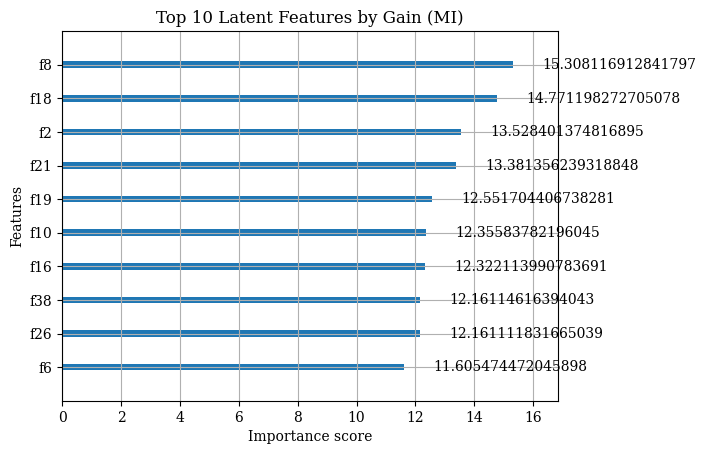


--- 2. SHAP Analysis for MI ---
Generating Global SHAP Summary Plot...


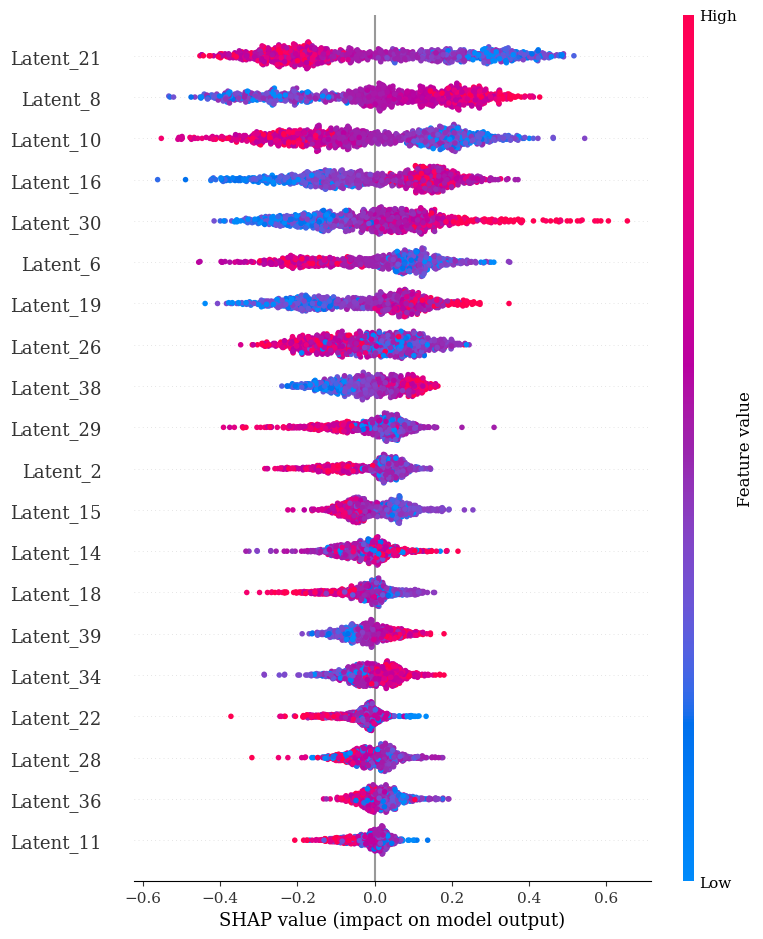

Generating Local SHAP Waterfall Plot for Patient 0...


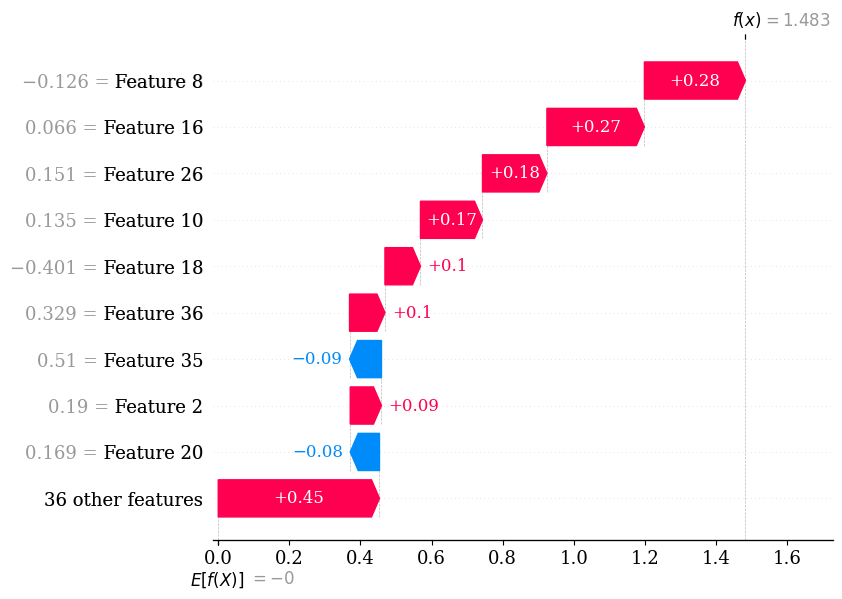


--- 3. Permutation Importance for MI ---


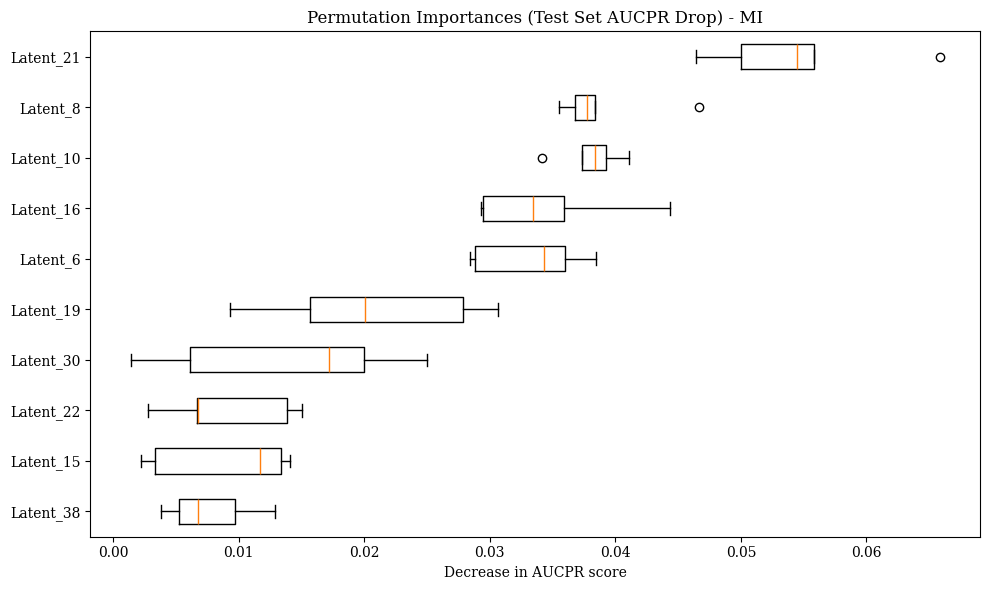


--- 4. Partial Dependence Plots for MI ---
Plotting PDP for top 3 features: ['Latent_8', 'Latent_18', 'Latent_2']


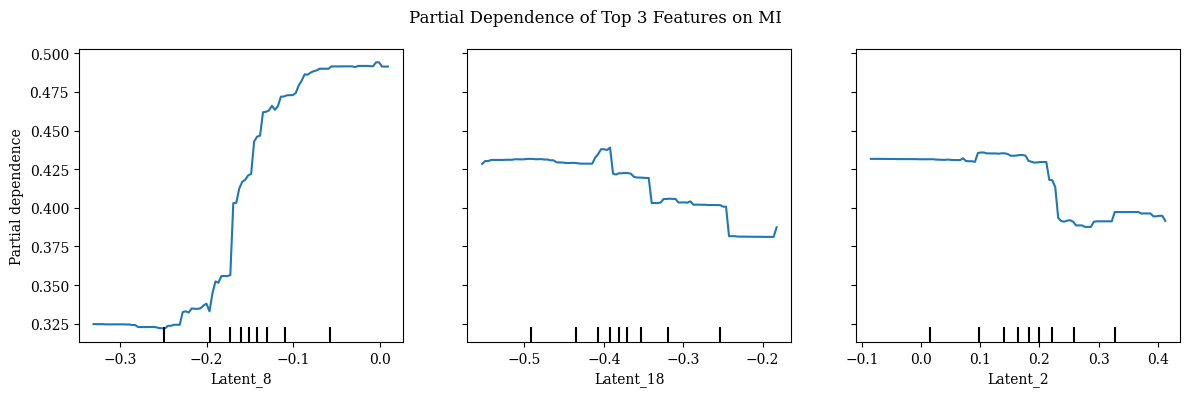

In [ ]:
# 1. Choose the target you want to explain (e.g., 'MI' or 'NORM')
TARGET_TO_EXPLAIN = 'MI'

# 2. Initialize the xAI Pipeline
xai = XAIPipeline(
    classifier=classifier,
    target_name=TARGET_TO_EXPLAIN,
    Z_train=Z_train,
    Z_test=Z_test,
    y_test=y_test
)

# 3. Execute the 4 techniques
xai.run_technique_1_native_importance()
xai.run_technique_2_shap_explanations()
xai.run_technique_3_permutation_importance()
xai.run_technique_4_partial_dependence()

Running Occlusion Sensitivity for Patient 0 on target: MI


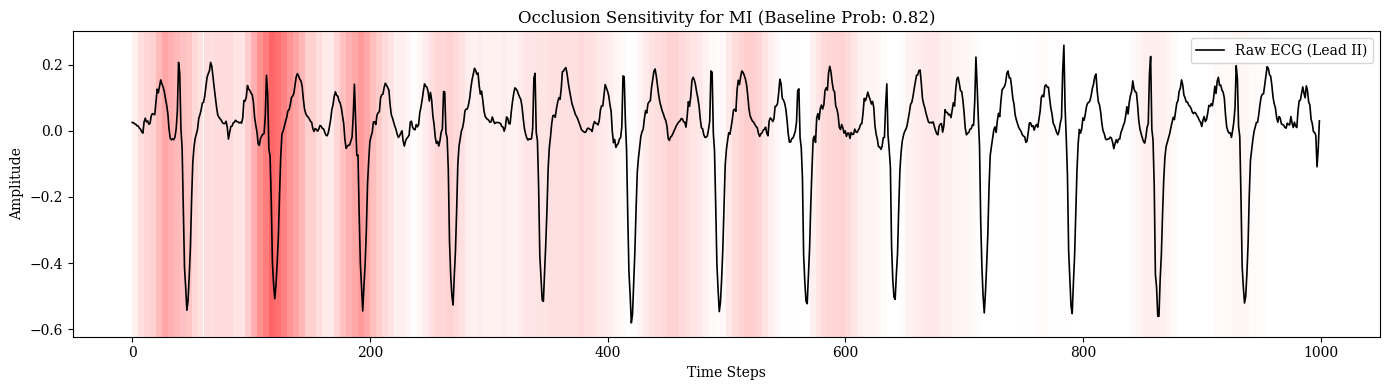

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_occlusion_sensitivity(patient_idx, target_class, window_size=20, stride=5):
    """
    Slides a 'flatline' window across the raw ECG and measures the drop in prediction probability.
    """
    print(f"Running Occlusion Sensitivity for Patient {patient_idx} on target: {target_class}")


    x_raw = X_test_raw[patient_idx:patient_idx+1].copy()


    x_proc = preprocessor.transform(x_raw)
    x_tensor = torch.tensor(x_proc, dtype=torch.float32).to(device)
    time_steps = torch.linspace(0., 1., x_tensor.shape[1]).to(device)

    with torch.no_grad():
        z_baseline = generative_ode.encoder(x_tensor, time_steps).cpu().numpy()

    target_idx = classifier.target_names.index(target_class)
    baseline_prob = classifier.predict_proba(z_baseline)[0, target_idx]

    sequence_length = x_raw.shape[1]
    importance_scores = np.zeros(sequence_length)

    for start in range(0, sequence_length - window_size, stride):
        end = start + window_size

        # Create a corrupted copy (flatline the window to 0)
        x_corrupted = x_raw.copy()
        x_corrupted[0, start:end, :] = 0

        # Run corrupted signal through pipeline
        x_corr_proc = preprocessor.transform(x_corrupted)
        x_corr_tensor = torch.tensor(x_corr_proc, dtype=torch.float32).to(device)

        with torch.no_grad():
            z_corrupted = generative_ode.encoder(x_corr_tensor, time_steps).cpu().numpy()

        corrupted_prob = classifier.predict_proba(z_corrupted)[0, target_idx]

        # The importance is how much the probability DROPPED
        drop = max(0, baseline_prob - corrupted_prob)
        importance_scores[start:end] += drop

    # Normalize scores for plotting
    if np.max(importance_scores) > 0:
        importance_scores = importance_scores / np.max(importance_scores)

    lead_idx = 1
    plt.figure(figsize=(14, 4))


    plt.plot(x_raw[0, :, lead_idx], color='black', linewidth=1.2, label='Raw ECG (Lead II)')

    # Fill the background with red intensity based on importance
    for t in range(sequence_length):
        plt.axvspan(t, t+1, color='red', alpha=importance_scores[t] * 0.6, lw=0)

    plt.title(f'Occlusion Sensitivity for {target_class} (Baseline Prob: {baseline_prob:.2f})')
    plt.xlabel('Time Steps')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example usage: Plot for patient 0, looking for 'MI'
plot_occlusion_sensitivity(patient_idx=0, target_class='MI', window_size=30, stride=5)

Most important feature for MI is Latent Dimension 8


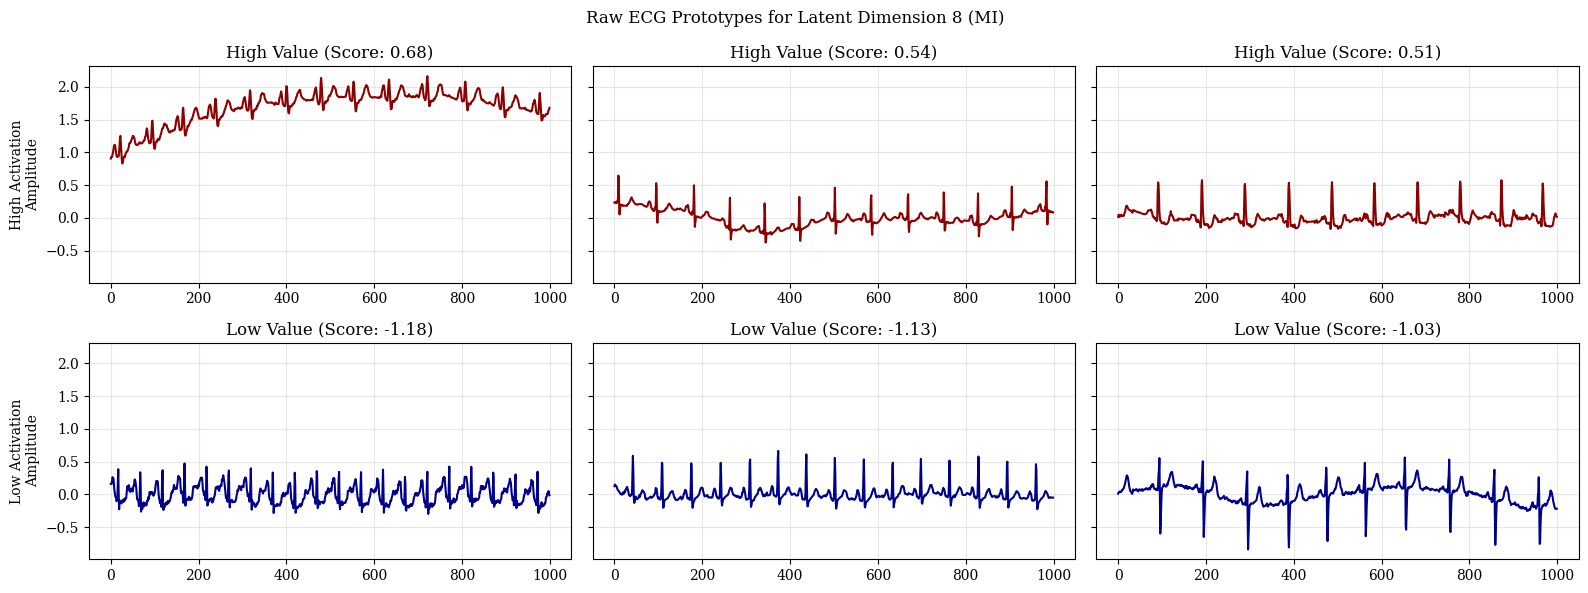

In [27]:
# ==========================================
# CELL 2: Latent Prototype Alignment
# ==========================================
import xgboost as xgb

def plot_latent_prototypes(target_class, top_n=3):
    """
    Finds the most important Latent Dimension for a target,
    and plots the ECGs of patients who scored highest and lowest on it.
    """
    target_idx = classifier.target_names.index(target_class)
    model = classifier.models[target_class]

    # 1. Find the most important feature (e.g., Latent_14) using XGBoost Gain
    importances = model.feature_importances_
    most_important_dim = np.argmax(importances)
    print(f"Most important feature for {target_class} is Latent Dimension {most_important_dim}")

    # 2. Find patients with the highest and lowest values for this dimension in the test set
    latent_values = Z_test[:, most_important_dim]

    highest_idx = np.argsort(latent_values)[-top_n:][::-1] # Top N
    lowest_idx = np.argsort(latent_values)[:top_n]         # Bottom N

    # 3. Plot them side-by-side
    fig, axes = plt.subplots(2, top_n, figsize=(16, 6), sharey=True)
    fig.suptitle(f'Raw ECG Prototypes for Latent Dimension {most_important_dim} ({target_class})')

    lead_idx = 1 # Lead II

    for i in range(top_n):
        # Plot Highest
        axes[0, i].plot(X_test_raw[highest_idx[i], :, lead_idx], color='darkred')
        axes[0, i].set_title(f'High Value (Score: {latent_values[highest_idx[i]]:.2f})')
        axes[0, i].grid(True, alpha=0.3)

        # Plot Lowest
        axes[1, i].plot(X_test_raw[lowest_idx[i], :, lead_idx], color='darkblue')
        axes[1, i].set_title(f'Low Value (Score: {latent_values[lowest_idx[i]]:.2f})')
        axes[1, i].grid(True, alpha=0.3)

    axes[0, 0].set_ylabel('High Activation\nAmplitude')
    axes[1, 0].set_ylabel('Low Activation\nAmplitude')
    plt.tight_layout()
    plt.show()

# Example usage: Find out what drives the 'NORM' or 'MI' prediction
plot_latent_prototypes(target_class='MI', top_n=3)

In [29]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7fa963fe30707080f5a5ee9f8b75bc4e97cd59b94f8440556c641a7ddc3bacaf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

def explain_patient_with_lime(patient_idx, target_class):
    """
    Uses LIME to explain the XGBoost prediction for a specific patient.
    """
    print(f"Generating LIME explanation for Patient {patient_idx} on target: {target_class}")
    target_idx = classifier.target_names.index(target_class)
    model = classifier.models[target_class]

    # 1. Setup the feature names (Latent_0, Latent_1, etc.)
    feature_names = [f"Latent_{i}" for i in range(Z_train.shape[1])]

    # 2. Initialize the LIME Explainer on the Training Data distribution
    explainer = LimeTabularExplainer(
        Z_train,
        feature_names=feature_names,
        class_names=['Negative', 'Positive'], # Binary classification per target
        mode='classification',
        random_state=42
    )

    # 3. Create a wrapper function that LIME can call
    # LIME expects a function that takes in 2D arrays and outputs probabilities
    def predict_fn(z_data):
        # model.predict_proba returns shape (N, 2) for binary log-loss
        return model.predict_proba(z_data)

    # 4. Explain the specific instance
    patient_z = Z_test[patient_idx]

    exp = explainer.explain_instance(
        data_row=patient_z,
        predict_fn=predict_fn,
        num_features=5 # Show top 5 contributing latent features
    )

    # 5. Display the visualization
    # This will render a nice HTML block directly in your Jupyter/Colab notebook
    exp.show_in_notebook(show_table=True)

# Example usage: Explain patient 0's diagnosis for CD (Conduction Disturbance)
explain_patient_with_lime(patient_idx=0, target_class='CD')

Generating LIME explanation for Patient 0 on target: CD


Generating LIME plot for Patient 0 on target: MI


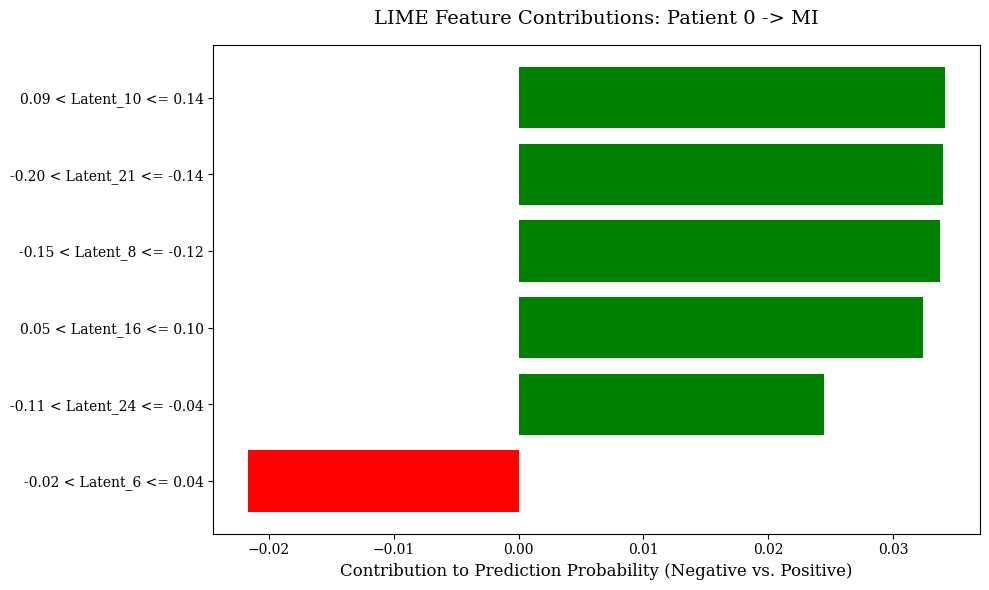

In [ ]:
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

def plot_patient_with_lime(patient_idx, target_class, num_features=5):
    """
    Uses LIME to explain the XGBoost prediction for a specific patient and plots it.
    """
    print(f"Generating LIME plot for Patient {patient_idx} on target: {target_class}")
    target_idx_loc = classifier.target_names.index(target_class)
    model = classifier.models[target_class]

    # 1. Setup the feature names
    feature_names = [f"Latent_{i}" for i in range(Z_train.shape[1])]

    # 2. Initialize the LIME Explainer
    explainer = LimeTabularExplainer(
        Z_train,
        feature_names=feature_names,
        class_names=['Negative', 'Positive'],
        mode='classification',
        random_state=42
    )

    # 3. Create the prediction wrapper
    def predict_fn(z_data):
        return model.predict_proba(z_data)

    # 4. Explain the specific instance
    patient_z = Z_test[patient_idx]

    exp = explainer.explain_instance(
        data_row=patient_z,
        predict_fn=predict_fn,
        num_features=num_features
    )

    # 5. Generate and customize the PyPlot figure
    fig = exp.as_pyplot_figure()

    # Optional: Make the plot look a bit cleaner
    fig.set_size_inches(10, 6)
    plt.title(f"LIME Feature Contributions: Patient {patient_idx} -> {target_class}", fontsize=14, pad=15)
    plt.xlabel("Contribution to Prediction Probability (Negative vs. Positive)", fontsize=12)
    plt.tight_layout()
    plt.show()

# Example usage: Plot the top 6 contributing features for Patient 0's MI diagnosis
plot_patient_with_lime(patient_idx=0, target_class='MI', num_features=6)